# Frequentist vs Bayesian Inference: A Simulation Study

In this note, we compare two ways to describe uncertainty about an unknown mean.

- **Frequentist route:** treat the parameter as fixed and study what the procedure does under repeated samples.
- **Bayesian route:** put a prior distribution on the parameter and update it to a posterior distribution after seeing data.

We generate data from a normal model, compute a confidence interval, compute two Bayesian credible interval (strong and weak priors), and compare the resulting statements.



### The comparison, as numbered steps

1. **Fix the truth**: choose $\mu_{true}$ and $\sigma$, set a seed, and simulate $n$ observations.
2. **Frequentist route**: compute the sample mean; run a z-test of $H_0: \mu = 0$; form the 95% confidence interval $\bar{x} \pm 1.96\,\sigma/\sqrt{n}$.
3. **Bayesian route**: state a prior $N(\mu_0, \tau_0^2)$; combine prior and data into the posterior $N(\mu_n, \tau_n^2)$; form the 95% credible interval $\mu_n \pm 1.96\,\tau_n$.
4. **Compare** both intervals to the known truth. One dataset is one anecdote --- to see the long-run picture, repeat steps 1--3 many times (the checks at the end do exactly this).


### 1. Data Generation


We simulate $n = 100$ observations from a normal distribution with true parameters $\mu = 2$ and $\sigma = 1$.

The true value $\mu = 2$ is shown in the plots so we can compare the methods against a known answer.


In [1]:
# --- Algorithm Step 1: fix the truth, then simulate --------------------------
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Set seed for reproducibility
np.random.seed(42)

# Parameters
# (the truth: every interval below will be judged against mu_true = 2)
mu_true = 2
sigma_true = 1
n = 100

# Generate data
# n draws from N(mu_true, sigma_true^2) -- the only randomness in the study
x = np.random.normal(loc=mu_true, scale=sigma_true, size=n)

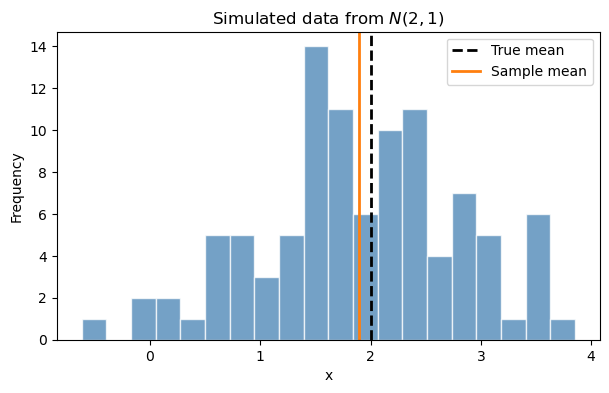

In [2]:
# Plot the generated data and mark the true mean.
plt.figure(figsize=(7, 4))
plt.hist(x, bins=20, edgecolor='white', alpha=0.75, color='steelblue')
plt.axvline(mu_true, color='black', linestyle='--', linewidth=2, label='True mean')
plt.axvline(np.mean(x), color='tab:orange', linewidth=2, label='Sample mean')
plt.title('Simulated data from $N(2, 1)$')
plt.xlabel('x')
plt.ylabel('Frequency')
plt.legend()
plt.show()


### 2. Frequentist Analysis


We now perform a frequentist analysis on the simulated data.

1. Estimate the sample mean.
2. Perform a one-sample z-test for $H_0: \mu = 0$ vs. $H_a: \mu \neq 0$, assuming known variance $\sigma^2 = 1$.
3. Construct a $95\%$ confidence interval for $\mu$.


In [3]:
# --- Algorithm Step 2: the frequentist route ---------------------------------
from scipy.stats import norm

# Step 1: Estimate sample mean
sample_mean = np.mean(x)

# Step 2: z-test with known sigma
# (under H0: mu = 0 the z-statistic is N(0,1); two-sided p-value)
z_stat = (sample_mean - 0) / (sigma_true / np.sqrt(n))
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# Step 3: 95% confidence interval
# (a promise about the PROCEDURE: over repeated samples, ~95% of such
#  intervals contain the fixed, non-random mu -- see check 1)
ci_lower = sample_mean - norm.ppf(0.975) * sigma_true / np.sqrt(n)
ci_upper = sample_mean + norm.ppf(0.975) * sigma_true / np.sqrt(n)

print(f"Sample mean: {sample_mean:.3f}")
print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"95% Confidence Interval for mu: ({ci_lower:.3f}, {ci_upper:.3f})")


Sample mean: 1.896
Z-statistic: 18.962
P-value: 0.0000
95% Confidence Interval for mu: (1.700, 2.092)


### 3. Bayesian Analysis


Given that the variance $\sigma^2 = 1$ is known, a convenient conjugate prior for the mean $\mu$ is a normal distribution
$$
\mu \sim N(\mu_0, \tau_0^2).
$$

For data $x_1, \ldots, x_n \sim N(\mu, \sigma^2)$, the posterior distribution is also normal:
$$
\mu \mid x \sim N\left(\mu_n, \tau_n^2\right),
$$
where
$$
\tau_n^2 = \left( \frac{n}{\sigma^2} + \frac{1}{\tau_0^2} \right)^{-1}, \qquad
\mu_n = \tau_n^2 \left(\frac{n\bar{x}}{\sigma^2} + \frac{\mu_0}{\tau_0^2}\right).
$$

We compare two priors:

- **Weak prior:** $\mu_0 = 0, \tau_0^2 = 10$
- **Strong prior:** $\mu_0 = 0, \tau_0^2 = 0.01$

Because the posterior is normal, the MAP estimate and posterior mean are the same.


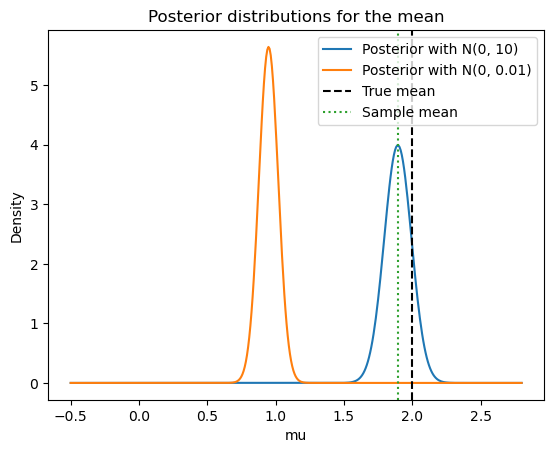

Posterior mean (N(0,10)): 1.894, 95% credible interval: (1.698, 2.090)
Posterior mean (N(0,0.01)): 0.948, 95% credible interval: (0.809, 1.087)


In [4]:
# --- Algorithm Step 3: the Bayesian route -------------------------------------

# Posterior calculation function
# Step 3 (update): precision-weighted compromise between prior and data:
#   tau_n^2 = 1 / (n/sigma^2 + 1/tau0^2)        (posterior variance)
#   mu_n    = tau_n^2 * (n*xbar/sigma^2 + mu0/tau0^2)   (posterior mean)
def compute_posterior(mu0, tau0_sq, xbar, n, sigma_sq):
    tau_n_sq = 1 / (n / sigma_sq + 1 / tau0_sq)
    mu_n = tau_n_sq * (n * xbar / sigma_sq + mu0 / tau0_sq)
    return mu_n, np.sqrt(tau_n_sq)

# Prior 1: N(0, 10)
mu1, std1 = compute_posterior(mu0=0, tau0_sq=10, xbar=sample_mean, n=n, sigma_sq=sigma_true**2)
# Prior 2: N(0, 0.01), a much stronger prior centered at 0
mu2, std2 = compute_posterior(mu0=0, tau0_sq=0.01, xbar=sample_mean, n=n, sigma_sq=sigma_true**2)

# Plot posteriors
# Step 4: compare -- both posteriors drawn against the known truth (dashed line)
x_vals = np.linspace(-0.5, 2.8, 400)
plt.plot(x_vals, stats.norm.pdf(x_vals, mu1, std1), label='Posterior with N(0, 10)')
plt.plot(x_vals, stats.norm.pdf(x_vals, mu2, std2), label='Posterior with N(0, 0.01)')
plt.axvline(mu_true, color='k', linestyle='--', label='True mean')
plt.axvline(sample_mean, color='tab:green', linestyle=':', label='Sample mean')
plt.title('Posterior distributions for the mean')
plt.xlabel('mu')
plt.ylabel('Density')
plt.legend()
plt.show()

# Credible intervals
# Step 3 (interval): a probability statement about mu GIVEN this dataset and prior
ci1 = (mu1 - 1.96 * std1, mu1 + 1.96 * std1)
ci2 = (mu2 - 1.96 * std2, mu2 + 1.96 * std2)

print(f"Posterior mean (N(0,10)): {mu1:.3f}, 95% credible interval: ({ci1[0]:.3f}, {ci1[1]:.3f})")
print(f"Posterior mean (N(0,0.01)): {mu2:.3f}, 95% credible interval: ({ci2[0]:.3f}, {ci2[1]:.3f})")


### 4. Compare the interval statements

The frequentist interval is about a procedure under repeated sampling. The Bayesian interval is about the parameter after choosing a prior and observing this dataset. In this simulation, we can also check whether each interval contains the true mean.


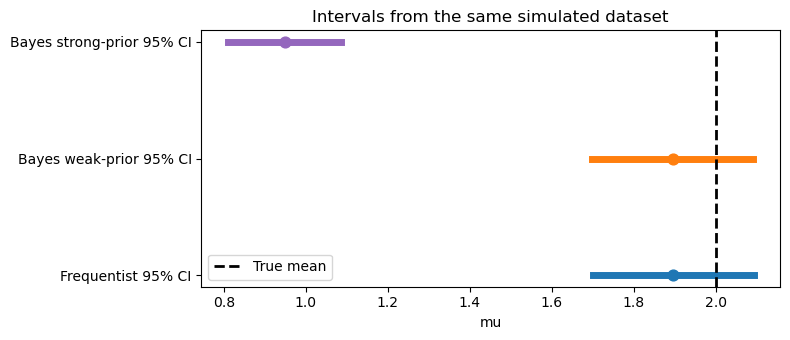

Frequentist 95% CI: contains true mean? True
Bayes weak-prior 95% CI: contains true mean? True
Bayes strong-prior 95% CI: contains true mean? False


In [5]:
intervals = [
    ('Frequentist 95% CI', ci_lower, ci_upper, 'tab:blue'),
    ('Bayes weak-prior 95% CI', ci1[0], ci1[1], 'tab:orange'),
    ('Bayes strong-prior 95% CI', ci2[0], ci2[1], 'tab:purple'),
]

plt.figure(figsize=(8, 3.5))
for y_pos, (label, lo, hi, color) in enumerate(intervals):
    plt.plot([lo, hi], [y_pos, y_pos], color=color, linewidth=5)
    plt.scatter([(lo + hi) / 2], [y_pos], color=color, s=60)
plt.axvline(mu_true, color='black', linestyle='--', linewidth=2, label='True mean')
plt.yticks(range(len(intervals)), [x[0] for x in intervals])
plt.xlabel('mu')
plt.title('Intervals from the same simulated dataset')
plt.legend()
plt.tight_layout()
plt.show()

for label, lo, hi, _ in intervals:
    print(f"{label}: contains true mean? {lo <= mu_true <= hi}")
